In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [2]:
train_dataset = torchvision.datasets.MNIST(
        root='.', 
        train=True, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])
    )

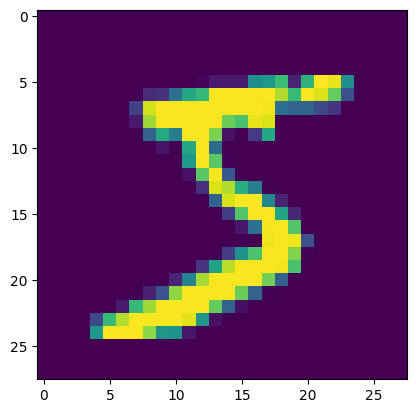

In [3]:
plt.imshow(train_dataset[0][0][0])

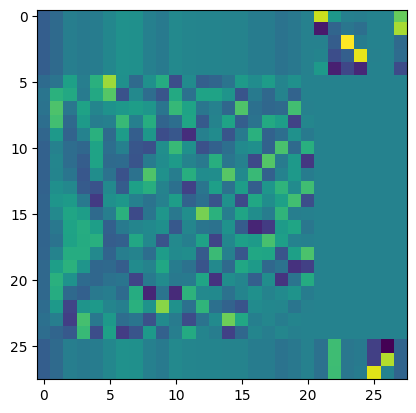

In [4]:
our_sample = train_dataset[0][0][0]

U, S, Vh = svd(our_sample, full_matrices=False)
V = Vh.T
plt.imshow(U)

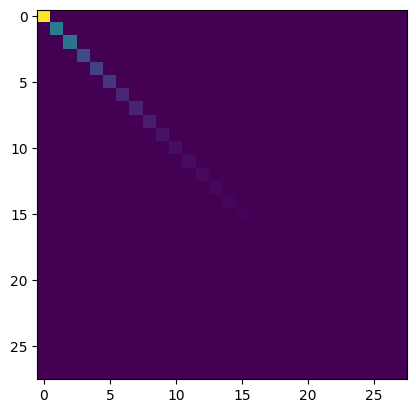

In [5]:
plt.imshow(torch.diag(S))

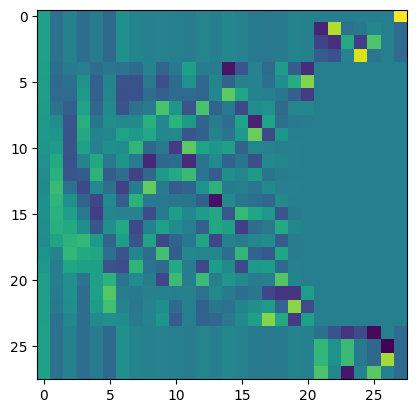

In [6]:
plt.imshow(V)

In [7]:
len(train_dataset)

60000

In [19]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        root='.', 
        train=False, 
        transform=transforms.ToTensor(),
    ),
    batch_size=128, shuffle=True
)

In [20]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
        emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = self.norm1(F.gelu(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(F.gelu(self.conv2(h)))
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        skip = self.conv(x, t_emb)
        return self.pool(skip), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x, t_emb)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
        super().__init__()
        
        self.time_proj = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )
        
        self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7
        
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        
        self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
        self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28
        
        self.out = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        '''
        :x input [bs, C, H, W] - image
        :t 1d torch.LongTensor of timesteps
        '''
        t_emb = self.time_proj(t)
        
        x, skip1 = self.down1(x, t_emb)
        x, skip2 = self.down2(x, t_emb)
        
        x = self.bottleneck(x, t_emb)
        
        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)
        
        return self.out(x)

In [21]:
DEVICE = "cuda"

In [22]:
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [23]:
sum([p.numel() for p in model.parameters()])

1910017

In [24]:
def svd_forward_process(image, t):
    U, S, Vh = svd(image, full_matrices=False)
    V = Vh.T
    
    U_slice = U[:, :t]
    V_slice = V[:, :t]
    S_slice = S[:t]

    restored = U_slice @ torch.diag(S_slice) @ V_slice.T
    
    return restored

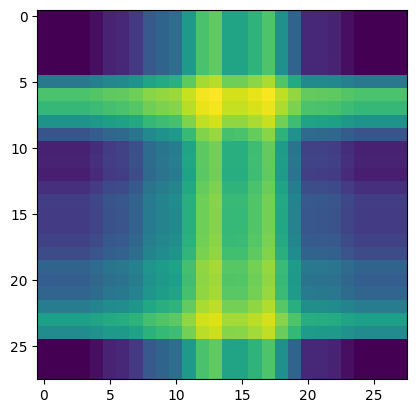

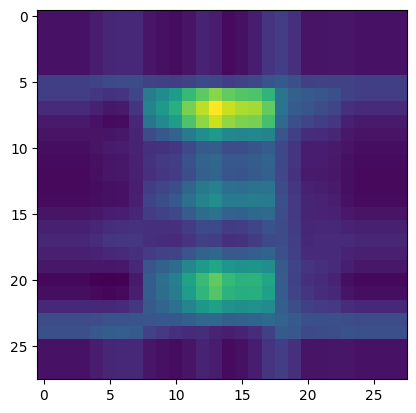

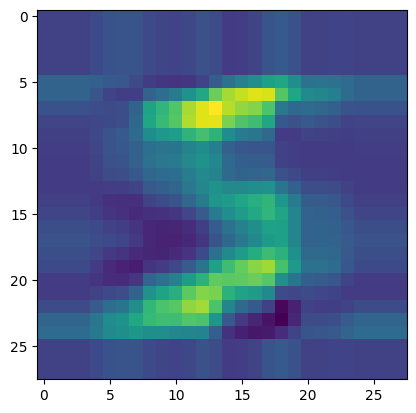

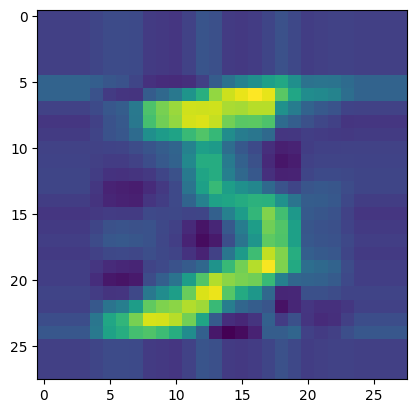

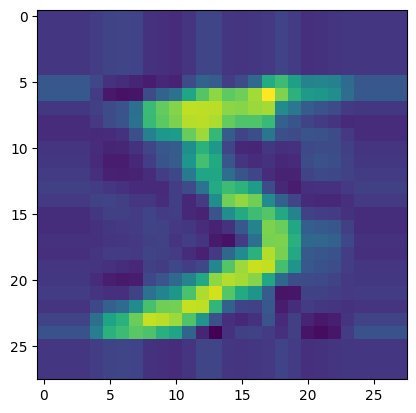

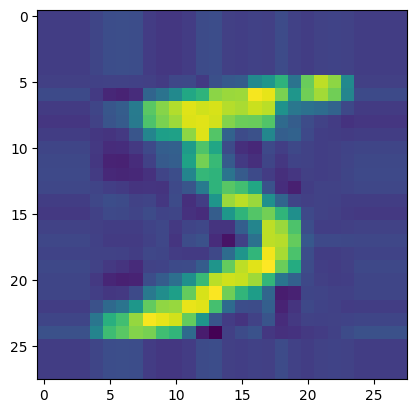

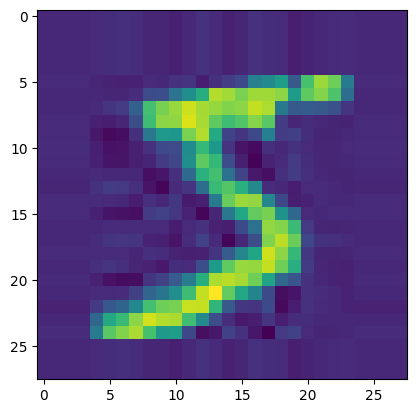

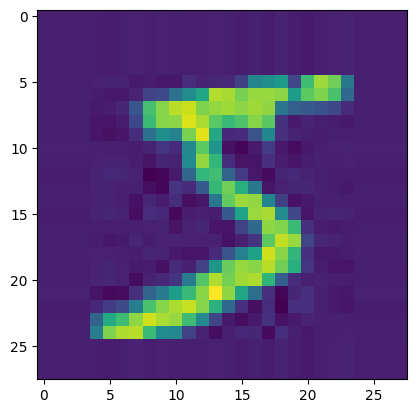

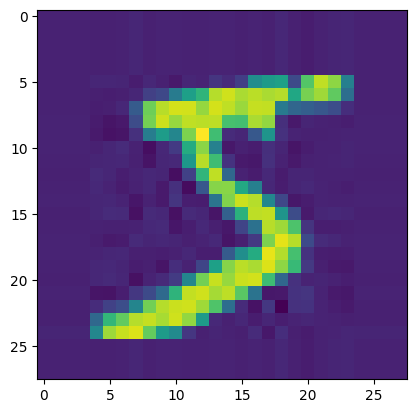

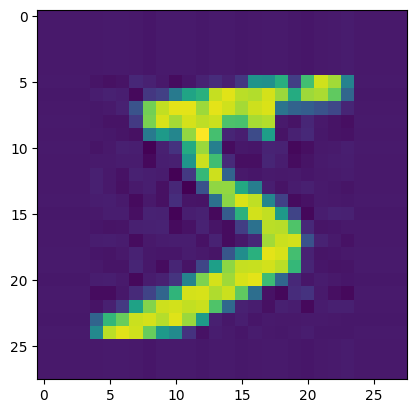

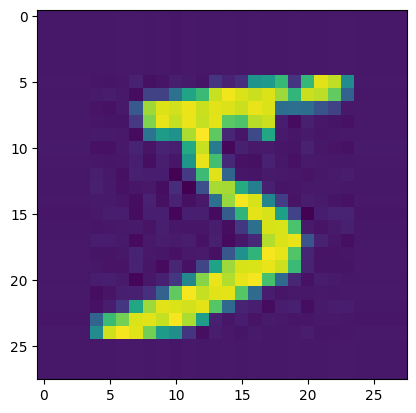

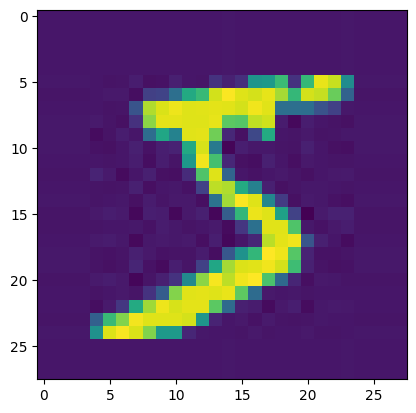

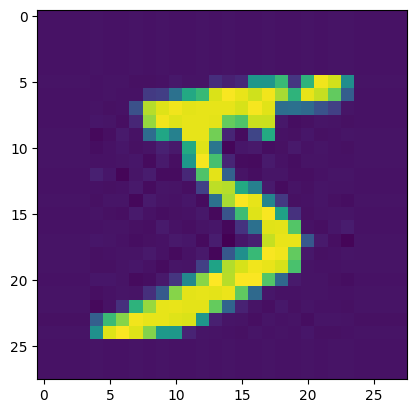

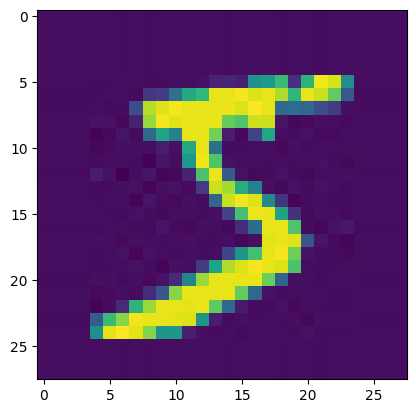

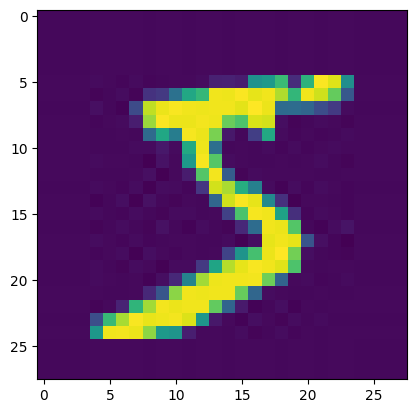

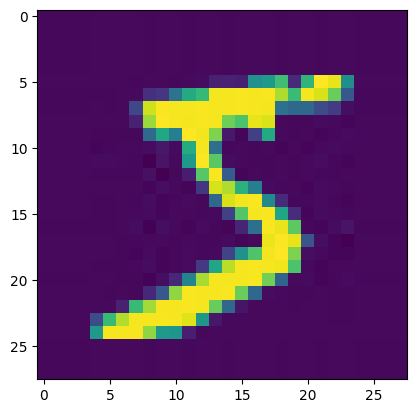

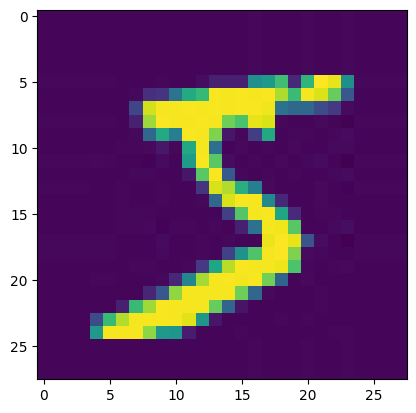

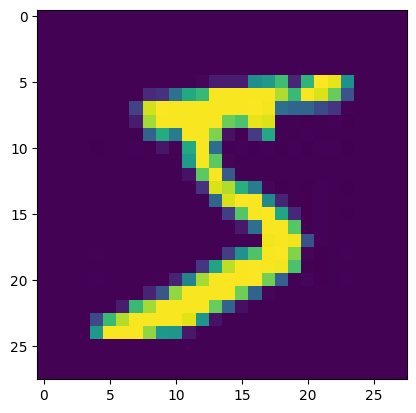

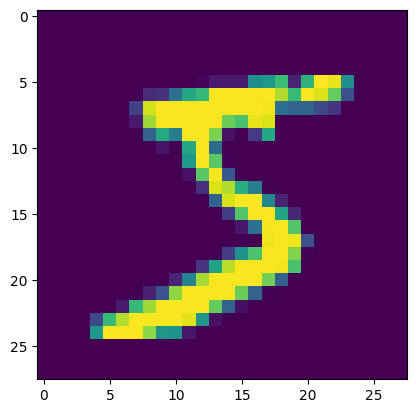

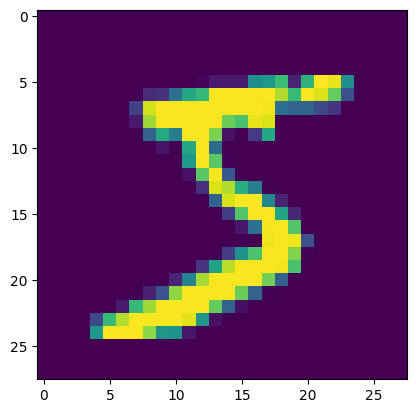

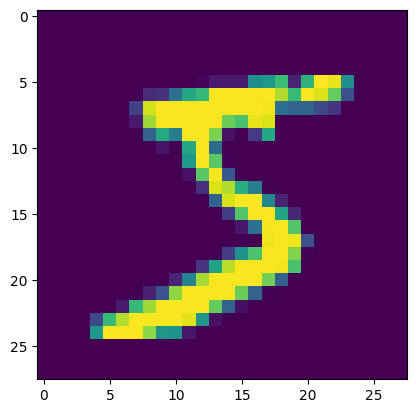

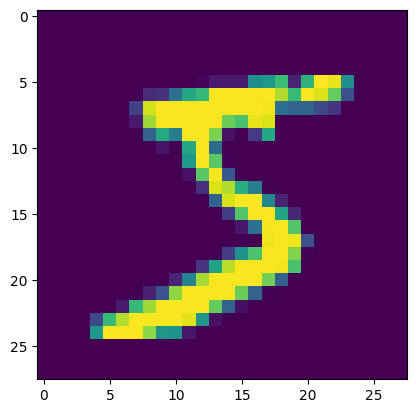

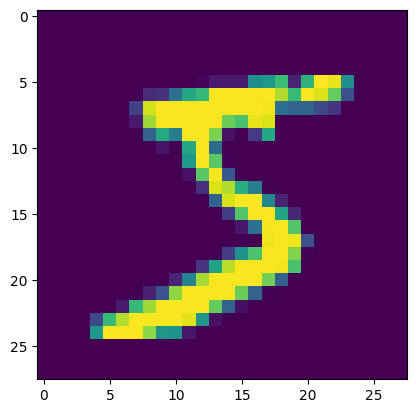

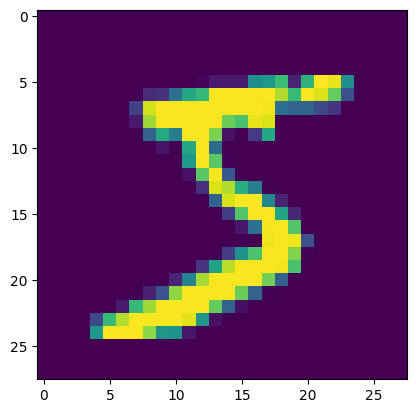

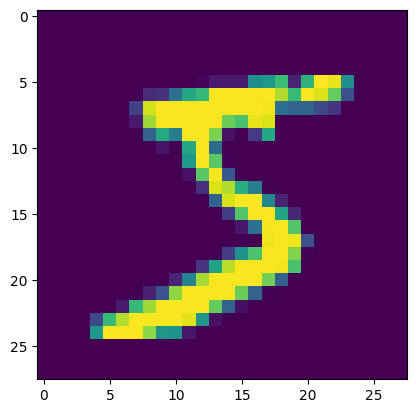

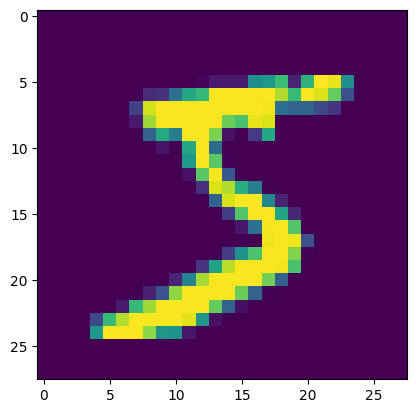

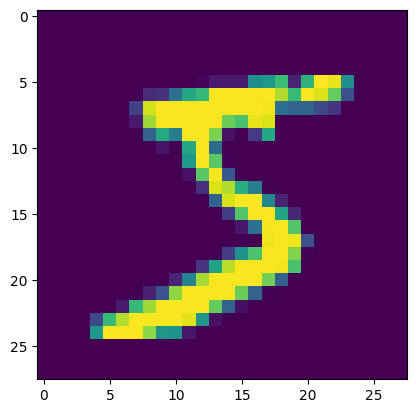

In [25]:
for n in range(1, 28):
    src = svd_forward_process(our_sample, n)
    plt.imshow(src)
    plt.show()

# Calculate Singular Values across Dataset

In [26]:
def get_scaled_singular_values(image):
    U, S, Vh = torch.linalg.svd(image, full_matrices=False)
    
    return S / torch.sum(S.flatten())

In [27]:
all_singular_weight = []

for i in tqdm(range(len(train_dataset))):
    all_singular_weight.append(get_scaled_singular_values(train_dataset[i][0][0]).unsqueeze(dim=0))

100%|██████████| 60000/60000 [00:07<00:00, 8049.47it/s]


In [28]:
weights = torch.mean(torch.cat(all_singular_weight, dim=0), dim=0)
weights.shape

torch.Size([28])

In [29]:
weights

tensor([3.9425e-01, 1.5373e-01, 1.1901e-01, 8.8725e-02, 6.5209e-02, 4.6306e-02,
        3.4102e-02, 2.4981e-02, 1.9028e-02, 1.4724e-02, 1.1543e-02, 8.8591e-03,
        6.7499e-03, 4.8303e-03, 3.3991e-03, 2.1376e-03, 1.3128e-03, 6.6371e-04,
        3.1318e-04, 9.7114e-05, 1.9004e-05, 2.2413e-08, 2.2410e-08, 2.2410e-08,
        2.2410e-08, 2.2410e-08, 2.2389e-08, 5.9256e-09])

# Train

In [30]:
losses = []

log_every_n = 10
num_train_steps = 1500
num_epoches = 10
step = 0 
HIGH = 28

model.train()

for epoch in range(num_epoches):
    for images, labels in tqdm(train_loader):
        batch_src = []
        batch_dst = []

        rec_step = torch.multinomial(weights, images.shape[0], replacement=True) + 1
                
        for i in range(images.shape[0]):
            our_sample = images[i][0]
            
            src = svd_forward_process(our_sample, rec_step[i])
            dst = svd_forward_process(our_sample, rec_step[i] + 1)

            batch_src.append(src.unsqueeze(dim=0).unsqueeze(dim=0))
            batch_dst.append(dst.unsqueeze(dim=0).unsqueeze(dim=0))

        src = torch.cat(batch_src, dim=0).to(DEVICE)
        dst = torch.cat(batch_dst, dim=0).to(DEVICE)
        
        target = dst.to(DEVICE)
        rec_step = rec_step.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, rec_step)

        loss = F.l1_loss(output, target)
    
        if step % log_every_n == 0:
            print(loss.item())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
        losses.append(loss.item())
    
        step += 1

        if step >= num_train_steps:
            break
            
    if step >= num_train_steps:
        break

  0%|          | 1/938 [00:00<08:04,  1.94it/s]

0.5263299345970154


  2%|▏         | 20/938 [00:00<00:29, 31.32it/s]

0.19066721200942993


  3%|▎         | 30/938 [00:01<00:23, 38.79it/s]

0.13690251111984253


  4%|▍         | 40/938 [00:01<00:20, 42.94it/s]

0.12597060203552246


  5%|▌         | 50/938 [00:01<00:19, 45.74it/s]

0.12367566674947739


  6%|▋         | 60/938 [00:01<00:18, 46.97it/s]

0.12589581310749054


  7%|▋         | 65/938 [00:01<00:19, 45.41it/s]

0.12312521040439606


  8%|▊         | 76/938 [00:02<00:18, 47.64it/s]

0.12075342983007431


  9%|▉         | 86/938 [00:02<00:19, 43.43it/s]

0.12655413150787354


 10%|█         | 97/938 [00:02<00:17, 46.82it/s]

0.11123076826334


 11%|█▏        | 107/938 [00:02<00:17, 47.95it/s]

0.1048026829957962
0.10900256782770157


 13%|█▎        | 125/938 [00:03<00:16, 50.01it/s]

0.10804019123315811
0.10835995525121689


 16%|█▌        | 147/938 [00:03<00:15, 49.59it/s]

0.09639988839626312


 17%|█▋        | 157/938 [00:03<00:15, 48.94it/s]

0.10980863869190216


 18%|█▊        | 167/938 [00:03<00:15, 49.18it/s]

0.12836723029613495
0.1139274314045906


 20%|██        | 188/938 [00:04<00:15, 47.95it/s]

0.11770382523536682


 21%|██        | 198/938 [00:04<00:15, 47.52it/s]

0.10357930511236191


 22%|██▏       | 208/938 [00:04<00:15, 47.25it/s]

0.10752709209918976


 23%|██▎       | 218/938 [00:05<00:15, 45.80it/s]

0.10989568382501602


 24%|██▍       | 228/938 [00:05<00:15, 45.13it/s]

0.1260230988264084


 25%|██▌       | 238/938 [00:05<00:15, 45.23it/s]

0.11006813496351242


 27%|██▋       | 249/938 [00:05<00:14, 47.58it/s]

0.10067861527204514
0.11959951370954514


 29%|██▉       | 270/938 [00:06<00:13, 49.12it/s]

0.11266466975212097
0.10367564857006073


 31%|███       | 287/938 [00:06<00:13, 49.70it/s]

0.10946989059448242


 32%|███▏      | 297/938 [00:06<00:13, 47.98it/s]

0.1098673939704895


 33%|███▎      | 307/938 [00:06<00:13, 48.34it/s]

0.1104547306895256


 34%|███▍      | 317/938 [00:07<00:12, 48.67it/s]

0.09705263376235962


 35%|███▍      | 327/938 [00:07<00:12, 48.45it/s]

0.097589872777462


 36%|███▌      | 337/938 [00:07<00:12, 47.44it/s]

0.11259775608778


 37%|███▋      | 348/938 [00:07<00:12, 48.30it/s]

0.09490913897752762


 38%|███▊      | 358/938 [00:08<00:11, 48.43it/s]

0.10285143554210663


 39%|███▉      | 369/938 [00:08<00:11, 48.89it/s]

0.09693922102451324


 40%|████      | 379/938 [00:08<00:11, 48.92it/s]

0.10956338793039322


 41%|████▏     | 389/938 [00:08<00:11, 49.00it/s]

0.09494730830192566


 43%|████▎     | 400/938 [00:08<00:10, 49.35it/s]

0.11007312685251236


 44%|████▎     | 410/938 [00:09<00:10, 49.19it/s]

0.08103341609239578


 44%|████▍     | 415/938 [00:09<00:10, 49.41it/s]

0.0971887931227684
0.09714648872613907


 47%|████▋     | 437/938 [00:09<00:10, 48.84it/s]

0.09498164802789688


 48%|████▊     | 447/938 [00:09<00:10, 47.07it/s]

0.09445971995592117


 49%|████▉     | 458/938 [00:10<00:10, 47.05it/s]

0.09523458033800125


 50%|████▉     | 468/938 [00:10<00:09, 47.04it/s]

0.08628899604082108


 51%|█████     | 478/938 [00:10<00:09, 46.88it/s]

0.09255541115999222


 52%|█████▏    | 488/938 [00:10<00:09, 46.25it/s]

0.08160527050495148


 53%|█████▎    | 498/938 [00:10<00:09, 47.33it/s]

0.09419314563274384


 54%|█████▍    | 508/938 [00:11<00:09, 47.68it/s]

0.09593561291694641


 55%|█████▌    | 518/938 [00:11<00:08, 48.17it/s]

0.08386716991662979


 56%|█████▋    | 528/938 [00:11<00:08, 47.97it/s]

0.09928874671459198


 57%|█████▋    | 538/938 [00:11<00:08, 48.28it/s]

0.10407704859972


 58%|█████▊    | 548/938 [00:11<00:08, 48.72it/s]

0.08694159984588623


 60%|█████▉    | 560/938 [00:12<00:07, 49.78it/s]

0.09569454193115234
0.09497751295566559


 62%|██████▏   | 578/938 [00:12<00:07, 50.18it/s]

0.09642645716667175
0.10328315943479538


 64%|██████▎   | 596/938 [00:12<00:06, 50.39it/s]

0.09967581927776337
0.08870930224657059


 66%|██████▌   | 620/938 [00:13<00:06, 51.32it/s]

0.10292426496744156
0.09355239570140839


 68%|██████▊   | 638/938 [00:13<00:05, 50.58it/s]

0.0991961807012558
0.10000167042016983


 70%|██████▉   | 656/938 [00:14<00:05, 50.73it/s]

0.08280370384454727
0.08763721585273743


 72%|███████▏  | 680/938 [00:14<00:05, 50.93it/s]

0.10570225119590759
0.0974167138338089


 74%|███████▍  | 698/938 [00:14<00:04, 50.26it/s]

0.0941348746418953
0.0924832820892334


 76%|███████▋  | 716/938 [00:15<00:04, 50.28it/s]

0.07837889343500137


 78%|███████▊  | 728/938 [00:15<00:04, 50.37it/s]

0.08781523257493973
0.08765508234500885


 80%|███████▉  | 746/938 [00:15<00:03, 50.39it/s]

0.08123406767845154


 81%|████████  | 758/938 [00:16<00:03, 50.34it/s]

0.10692718625068665
0.08105012774467468


 83%|████████▎ | 776/938 [00:16<00:03, 50.56it/s]

0.10300978273153305
0.08621962368488312


 85%|████████▌ | 800/938 [00:16<00:02, 50.16it/s]

0.09489203244447708
0.0762309804558754


 87%|████████▋ | 818/938 [00:17<00:02, 50.15it/s]

0.08905373513698578


 88%|████████▊ | 829/938 [00:17<00:02, 48.13it/s]

0.08853388577699661


 89%|████████▉ | 839/938 [00:17<00:02, 45.91it/s]

0.08186177909374237


 91%|█████████ | 849/938 [00:17<00:01, 46.43it/s]

0.09142196178436279


 92%|█████████▏| 859/938 [00:18<00:01, 46.73it/s]

0.08044419437646866


 93%|█████████▎| 869/938 [00:18<00:01, 46.51it/s]

0.08090206235647202


 94%|█████████▎| 879/938 [00:18<00:01, 43.65it/s]

0.09048274904489517


 95%|█████████▍| 890/938 [00:18<00:01, 46.80it/s]

0.0831759124994278
0.08958732336759567


 97%|█████████▋| 907/938 [00:19<00:00, 49.20it/s]

0.10943035036325455
0.08153007924556732


 99%|█████████▊| 925/938 [00:19<00:00, 49.95it/s]

0.08834953606128693
0.09525306522846222


  1%|          | 11/938 [00:00<00:18, 51.03it/s]

0.09467710554599762
0.09290146827697754


  3%|▎         | 29/938 [00:00<00:17, 52.01it/s]

0.08710338175296783
0.08524202555418015


  6%|▌         | 53/938 [00:01<00:17, 51.68it/s]

0.10101506114006042
0.07794719934463501


  8%|▊         | 71/938 [00:01<00:16, 51.02it/s]

0.08053213357925415
0.10046940296888351


  9%|▉         | 89/938 [00:01<00:16, 51.03it/s]

0.10033312439918518
0.07981368154287338


 12%|█▏        | 113/938 [00:02<00:16, 51.38it/s]

0.09050744026899338
0.08099368214607239


 14%|█▍        | 131/938 [00:02<00:15, 51.39it/s]

0.09155003726482391
0.08093828707933426


 16%|█▌        | 149/938 [00:02<00:15, 51.36it/s]

0.08195384591817856
0.08498835563659668


 18%|█▊        | 173/938 [00:03<00:15, 50.67it/s]

0.09226751327514648
0.08597445487976074


 20%|██        | 191/938 [00:03<00:14, 49.92it/s]

0.07674932479858398


 22%|██▏       | 202/938 [00:03<00:14, 50.66it/s]

0.09164603799581528
0.08297184109687805


 23%|██▎       | 220/938 [00:04<00:14, 51.20it/s]

0.0949486494064331
0.0826144888997078


 25%|██▌       | 238/938 [00:04<00:13, 51.72it/s]

0.08679361641407013
0.076063372194767


 28%|██▊       | 262/938 [00:05<00:13, 50.67it/s]

0.08215746283531189
0.0863109901547432


 30%|██▉       | 280/938 [00:05<00:12, 51.51it/s]

0.09986568987369537
0.08434557914733887


 32%|███▏      | 298/938 [00:05<00:12, 51.43it/s]

0.0820271298289299
0.07034710049629211


 34%|███▍      | 322/938 [00:06<00:12, 51.32it/s]

0.08104277402162552
0.08526773005723953


 36%|███▌      | 340/938 [00:06<00:11, 50.98it/s]

0.06973978132009506
0.08448366820812225


 38%|███▊      | 358/938 [00:06<00:11, 51.27it/s]

0.08885881304740906
0.08202569931745529


 41%|████      | 382/938 [00:07<00:10, 51.80it/s]

0.08116637170314789
0.0875605121254921


 43%|████▎     | 400/938 [00:07<00:10, 49.88it/s]

0.07976362854242325


 44%|████▍     | 412/938 [00:08<00:10, 50.60it/s]

0.08040880411863327
0.08688987046480179


 46%|████▌     | 430/938 [00:08<00:09, 51.04it/s]

0.087478868663311
0.08714639395475388


 48%|████▊     | 448/938 [00:08<00:09, 50.27it/s]

0.0660696029663086


 49%|████▉     | 460/938 [00:09<00:09, 49.88it/s]

0.08724505454301834
0.09139029681682587


 51%|█████     | 478/938 [00:09<00:09, 50.57it/s]

0.07942315191030502
0.0771649032831192


 54%|█████▎    | 502/938 [00:09<00:08, 50.77it/s]

0.08937516063451767
0.08102697134017944


 55%|█████▌    | 520/938 [00:10<00:08, 50.94it/s]

0.08248601108789444
0.09003119170665741


 57%|█████▋    | 538/938 [00:10<00:07, 51.06it/s]

0.06838653981685638
0.0829770416021347


 60%|█████▉    | 561/938 [00:11<00:07, 50.96it/s]

0.09154220670461655


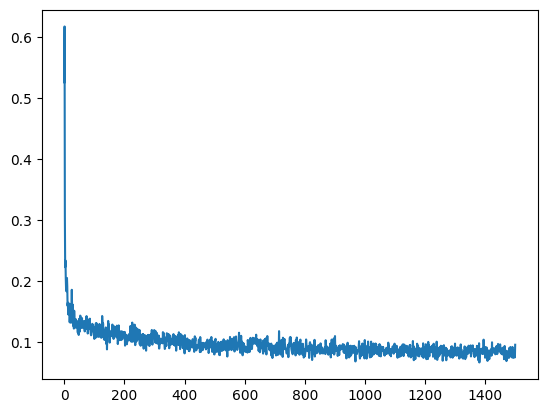

In [31]:
plt.plot([i for i in range(len(losses))], losses)

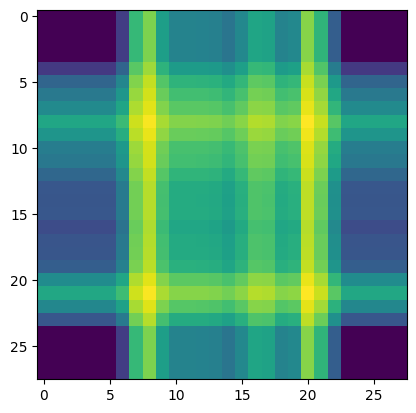

In [34]:
src = svd_forward_process(train_dataset[1][0][0], 1)

plt.imshow(src)

MovieWriter ffmpeg unavailable; using Pillow instead.


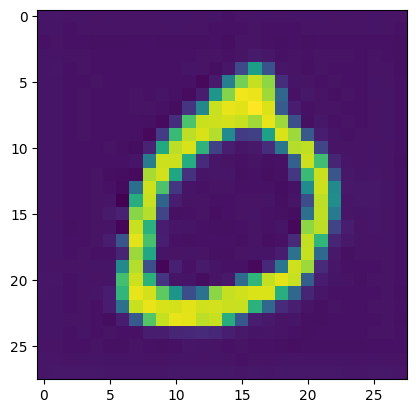

In [35]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_generation.gif')

# Fit Prior

In [36]:
from sklearn.mixture import GaussianMixture
import numpy as np


def get_rank1_scaled(image):
    U, S, Vh = torch.linalg.svd(image, full_matrices=False)
    
    # Get rank-1 components
    u1 = U[:, 0]  # shape (28,)
    v1 = Vh[0, :]  # shape (28,) - Note: Vh[0] not V[:, 0]
    sigma1 = S[0]  # scalar
    
    # SCALE the vectors by √σ₁ to preserve reconstruction
    u_scaled = u1 * torch.sqrt(sigma1)
    v_scaled = v1 * torch.sqrt(sigma1)
    
    # Concatenate: [√σ*u, √σ*v, σ]
    # This preserves the outer product relationship
    return torch.cat([u_scaled, v_scaled, sigma1.unsqueeze(0)]).unsqueeze(0)

# Reconstruction from this format:
def reconstruct_from_scaled(vector):
    u_scaled = vector[:28]
    v_scaled = vector[28:56]
    sigma = vector[56]
    
    # image = (√σ*u) ⊗ (√σ*v) = σ * (u ⊗ v)
    image = torch.outer(u_scaled, v_scaled)
    return image

In [37]:
X = []

for i in tqdm(range(len(train_dataset))):
    X.append(get_rank1_scaled(train_dataset[i][0][0]))
    
X = torch.cat(X)
X.shape

100%|██████████| 60000/60000 [00:08<00:00, 7074.16it/s]


torch.Size([60000, 57])

In [38]:
n_components = 10
gmm = GaussianMixture(n_components=n_components, covariance_type='full', verbose=2, random_state=42)
gmm.fit(X.numpy())

Initialization 0
  Iteration 10	 time lapse 8.34579s	 ll change 0.33705
  Iteration 20	 time lapse 7.77193s	 ll change 0.04277
  Iteration 30	 time lapse 7.59950s	 ll change 0.01363
Initialization converged. time lapse 29.21874s	 lower bound 136.16582.


,n_components,10
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [39]:
sampled_vectors = gmm.sample(n_samples=100)[0]
sampled_vectors.shape

/home/user/conda/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


(100, 57)

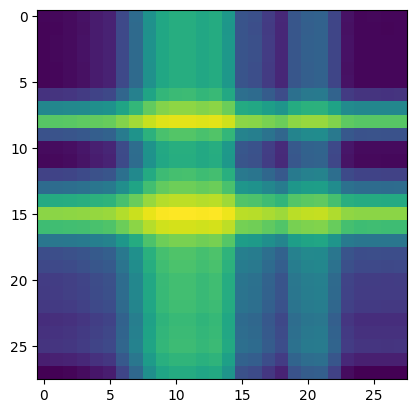

In [48]:
src = reconstruct_from_scaled(torch.tensor(sampled_vectors[3])).float()
plt.imshow(src)

MovieWriter ffmpeg unavailable; using Pillow instead.


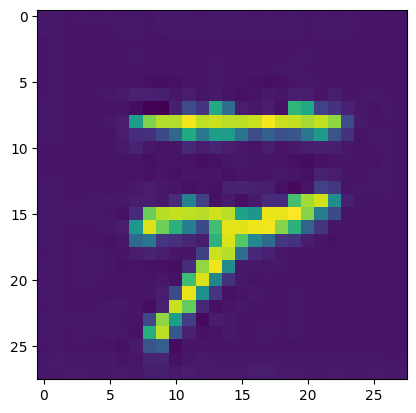

In [49]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_generation.gif')

In [55]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(4):
    save_dir = f'MNIST/generate_svd_markovian/{num_steps}'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
        
        sampled_vectors = gmm.sample(n_samples=batch_size)[0]
        x_t = torch.cat([reconstruct_from_scaled(torch.tensor(v).float())[None, None] for v in sampled_vectors], dim=0).to(DEVICE)
                
        with torch.no_grad():
            for t in range(1, num_steps):
                x_t = model(
                    x_t.to(DEVICE), 
                    torch.tensor(t).repeat(x_t.shape[0]).to(DEVICE)
                )
        
        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

    print(f'Saved {count} generated images to {save_dir}')

Generating and saving images:   0%|          | 0/10 [00:00<?, ?it/s]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Generating and saving images: 100%|██████████| 10/10 [00:16<00:00,  1.67s/it]


Saved 10000 generated images to MNIST/generate_svd_markovian/0


Generating and saving images: 100%|██████████| 10/10 [00:16<00:00,  1.60s/it]


Saved 10000 generated images to MNIST/generate_svd_markovian/1


Generating and saving images: 100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


Saved 10000 generated images to MNIST/generate_svd_markovian/2


Generating and saving images: 100%|██████████| 10/10 [00:15<00:00,  1.57s/it]

Saved 10000 generated images to MNIST/generate_svd_markovian/3


In [65]:
import pandas as pd

fid_results = "fid_svd_markovian_results.csv"
df = pd.read_csv(fid_results)
df = df.iloc[1:]

In [68]:
df["steps"] = df["path1"].apply(lambda x: int(x.split("_")[-1].split("/")[-1]))

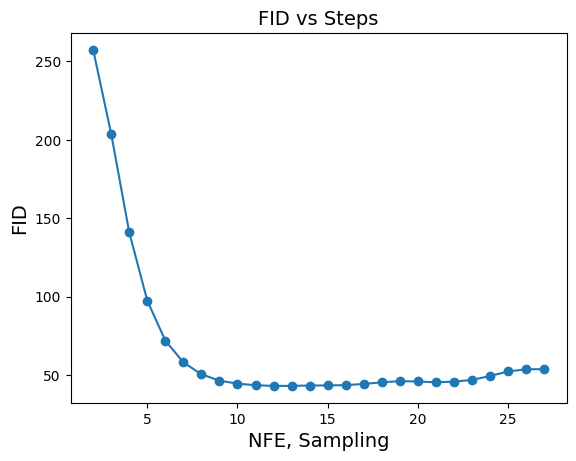

In [69]:
plt.plot(df["steps"], df["fid"], "-o")
plt.xlabel("NFE, Sampling", fontsize=14)
plt.ylabel("FID", fontsize=14)
plt.title("FID vs Steps", fontsize=14)
plt.show()